In [1]:
import sys
sys.path.append('..')

from matplotlib import pyplot as plt
from src.analysis import break_even_analysis, comparative_statics, stochastic_bivariate_simulation, run_monte_carlo, \
    run_two_way_sensitivity_analysis
from src.config import variable_names
from src.engine import evaluate_chained_models, evaluate_variable_scenario_sweep, evaluate_expected_scenario
from src.models import ProfitModel, CostOfGoodsSoldModel, RevenueModel, FreeCashFlowModel, \
    CapitalExpenditureModel, DepreciationModel, TotalExpenseModel, NetIncomeModel, RoiModel, TotalCostModel, \
    AdvertisingEfficiencyModel
from src.variables import Orders, SellingPrice, PurchasingPrice, ItemsPerOrder, USDToRMB, Rent, TaxRate, \
    CostPerAcquisition, ConversionRate, RenderFee, TravelFee, AdvertisingCost, Expense
from src.visualization import generate_heatmap_from_df

In [2]:
advertising_budget = AdvertisingCost(min_value=10000, max_value=30000)
orders = Orders(min_value=20, max_value=30)
# usd_to_rmb = USDToRMB(expected_value=1, min_value=6.0, max_value=7.5)
selling_price = SellingPrice(min_value=3000, max_value=6000)
items_per_order = ItemsPerOrder(min_value=1, max_value=5)
purchasing_price = PurchasingPrice(min_value=1000, max_value=2000)
conversion_rate = ConversionRate(min_value=0.04, max_value=0.2)
cpa = CostPerAcquisition(min_value=12, max_value=36)

variables = {variable_names.DEAL_ORDERS: orders,
             variable_names.COST_CPA: cpa,
             variable_names.COST_CONVERSION_RATE: conversion_rate,
             variable_names.DEAL_SELLING_PRICE: selling_price,
             variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
             variable_names.COST_ADVERTISING: advertising_budget,
             # variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
             variable_names.DEAL_ITEMS_PER_ORDER: items_per_order}

cogs_model = CostOfGoodsSoldModel()
cost_model = TotalCostModel()
revenue_model = RevenueModel()
expense_model = TotalExpenseModel()
depreciation_model = DepreciationModel()
capital_expenditure_model = CapitalExpenditureModel()
net_income_model = NetIncomeModel()
advertising_efficiency_model = AdvertisingEfficiencyModel()
# free_cash_flow_model = FreeCashFlowModel()
profit_model = ProfitModel()
# roi_model = RoiModel()

In [3]:
two_way_analysis_df_with_meaningless_order = run_two_way_sensitivity_analysis(variables, param_x_name=variable_names.DEAL_ORDERS,
                                                       param_y_name=variable_names.DEAL_SELLING_PRICE,
                                                       model_pipeline=[advertising_efficiency_model,
                                                                       cogs_model, revenue_model, cost_model,
                                                                       expense_model,
                                                                       depreciation_model, net_income_model,
                                                                       capital_expenditure_model, profit_model],
                                                       target_output_name=variable_names.PROFIT,
                                                       x_steps=10, y_steps=5)

In [4]:
print(two_way_analysis_df_with_meaningless_order)

Orders          20.0000    21.1111    22.2222    23.3333    24.4444  \
SellingPrice                                                          
6000.0        1330000.0  1330000.0  1330000.0  1330000.0  1330000.0   
5250.0        1105000.0  1105000.0  1105000.0  1105000.0  1105000.0   
4500.0         880000.0   880000.0   880000.0   880000.0   880000.0   
3750.0         655000.0   655000.0   655000.0   655000.0   655000.0   
3000.0         430000.0   430000.0   430000.0   430000.0   430000.0   

Orders          25.5556    26.6667    27.7778    28.8889    30.0000  
SellingPrice                                                         
6000.0        1330000.0  1330000.0  1330000.0  1330000.0  1330000.0  
5250.0        1105000.0  1105000.0  1105000.0  1105000.0  1105000.0  
4500.0         880000.0   880000.0   880000.0   880000.0   880000.0  
3750.0         655000.0   655000.0   655000.0   655000.0   655000.0  
3000.0         430000.0   430000.0   430000.0   430000.0   430000.0  


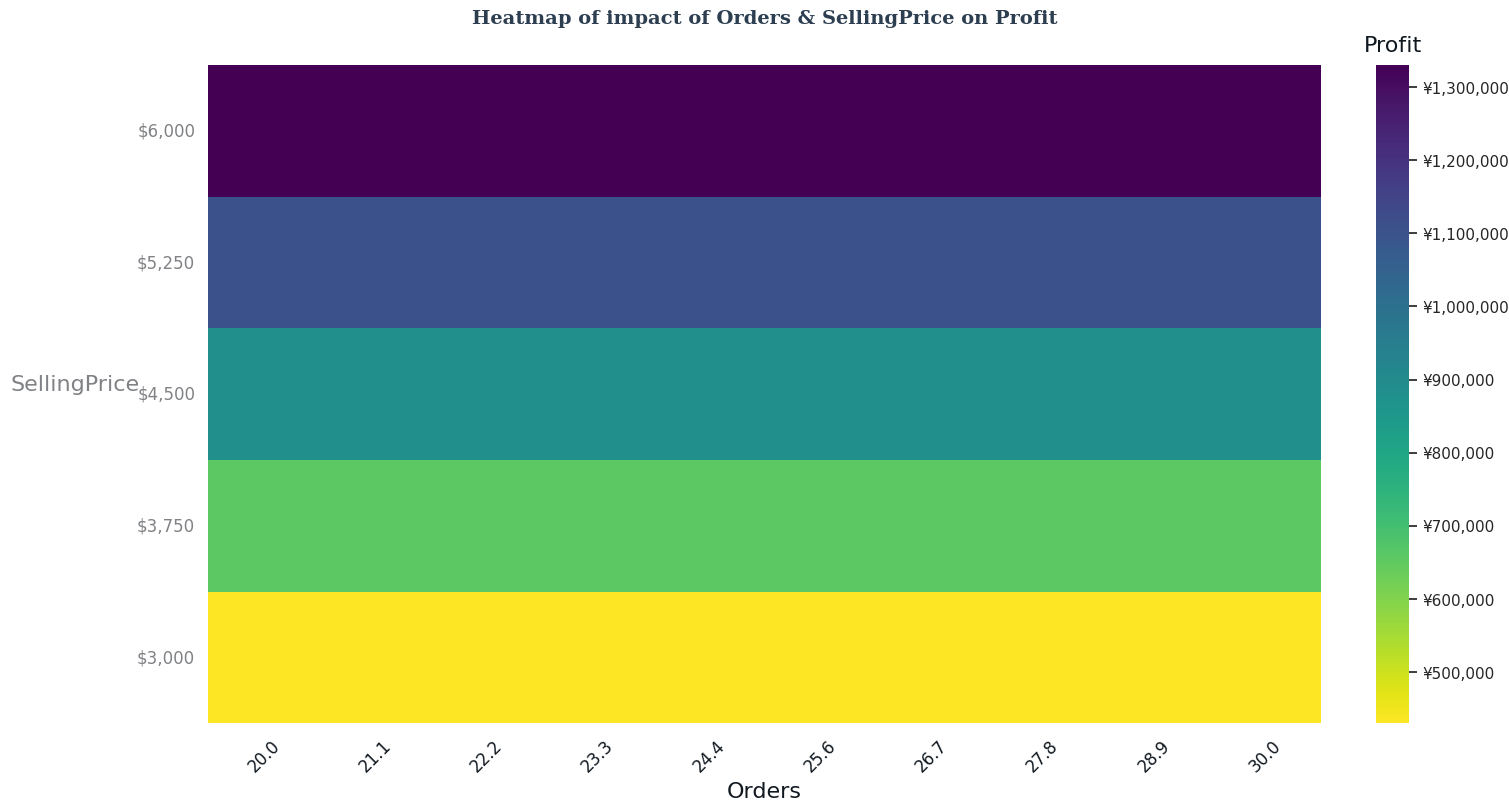

In [5]:
figure = generate_heatmap_from_df(two_way_analysis_df_with_meaningless_order, variable_names.PROFIT)
plt.show()

In [6]:
two_way_analysis_df_with_upside_y_axis = run_two_way_sensitivity_analysis(variables, param_x_name=variable_names.COST_ADVERTISING,
                                                       param_y_name=variable_names.DEAL_SELLING_PRICE,
                                                       model_pipeline=[advertising_efficiency_model,
                                                                       cogs_model, revenue_model, cost_model,
                                                                       expense_model,
                                                                       depreciation_model, net_income_model,
                                                                       capital_expenditure_model, profit_model],
                                                       target_output_name=variable_names.PROFIT,
                                                       x_steps=30, y_steps=20, reverse_y=False)

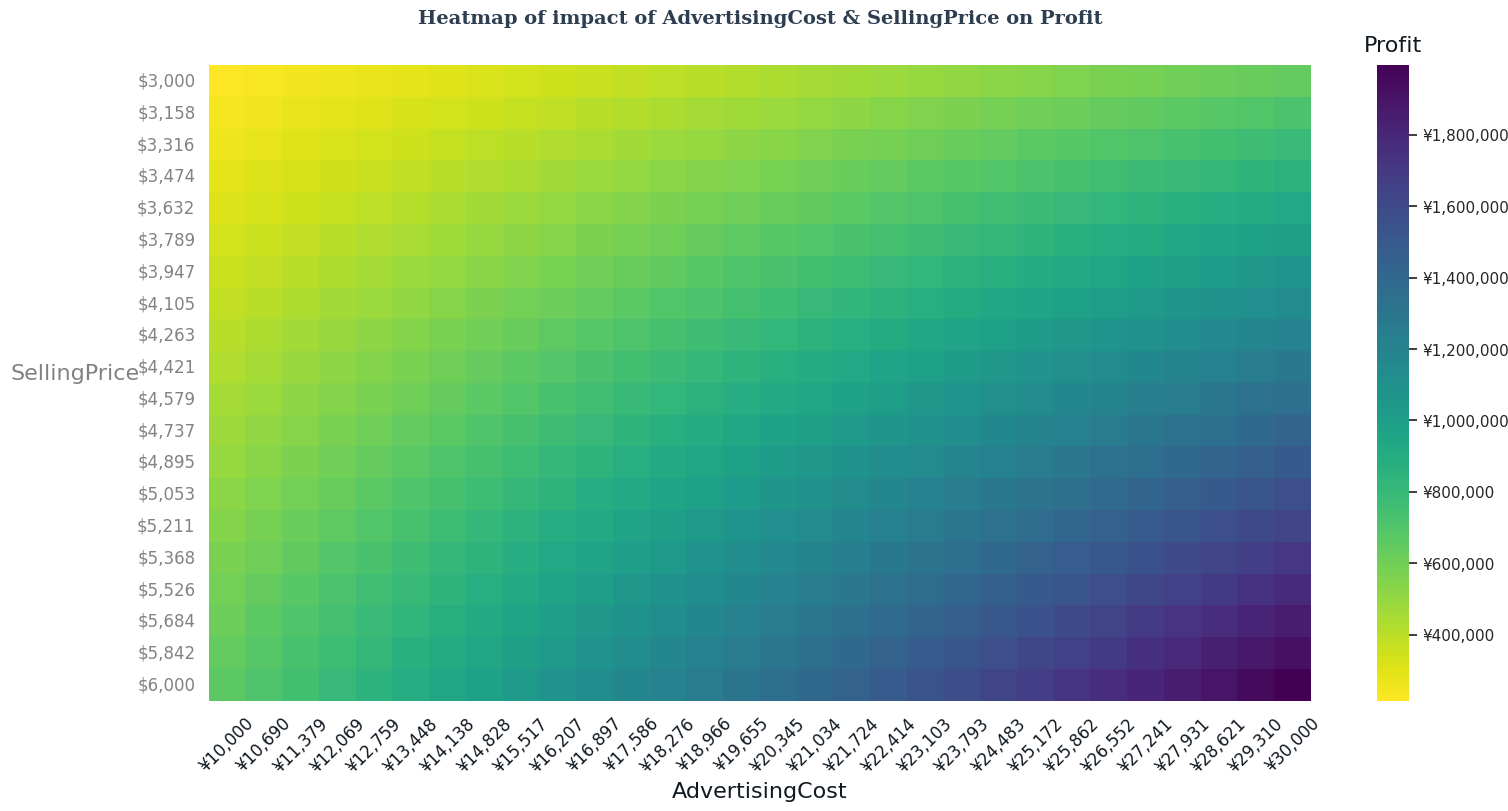

In [7]:
figure = generate_heatmap_from_df(two_way_analysis_df_with_upside_y_axis, variable_names.PROFIT)
plt.show()

In [8]:
two_way_analysis_df = run_two_way_sensitivity_analysis(variables, param_x_name=variable_names.COST_ADVERTISING,
                                                       param_y_name=variable_names.DEAL_SELLING_PRICE,
                                                       model_pipeline=[advertising_efficiency_model,
                                                                       cogs_model, revenue_model, cost_model,
                                                                       expense_model,
                                                                       depreciation_model, net_income_model,
                                                                       capital_expenditure_model, profit_model],
                                                       target_output_name=variable_names.PROFIT,
                                                       x_steps=30, y_steps=20)

In [9]:
# print(two_way_analysis_df)

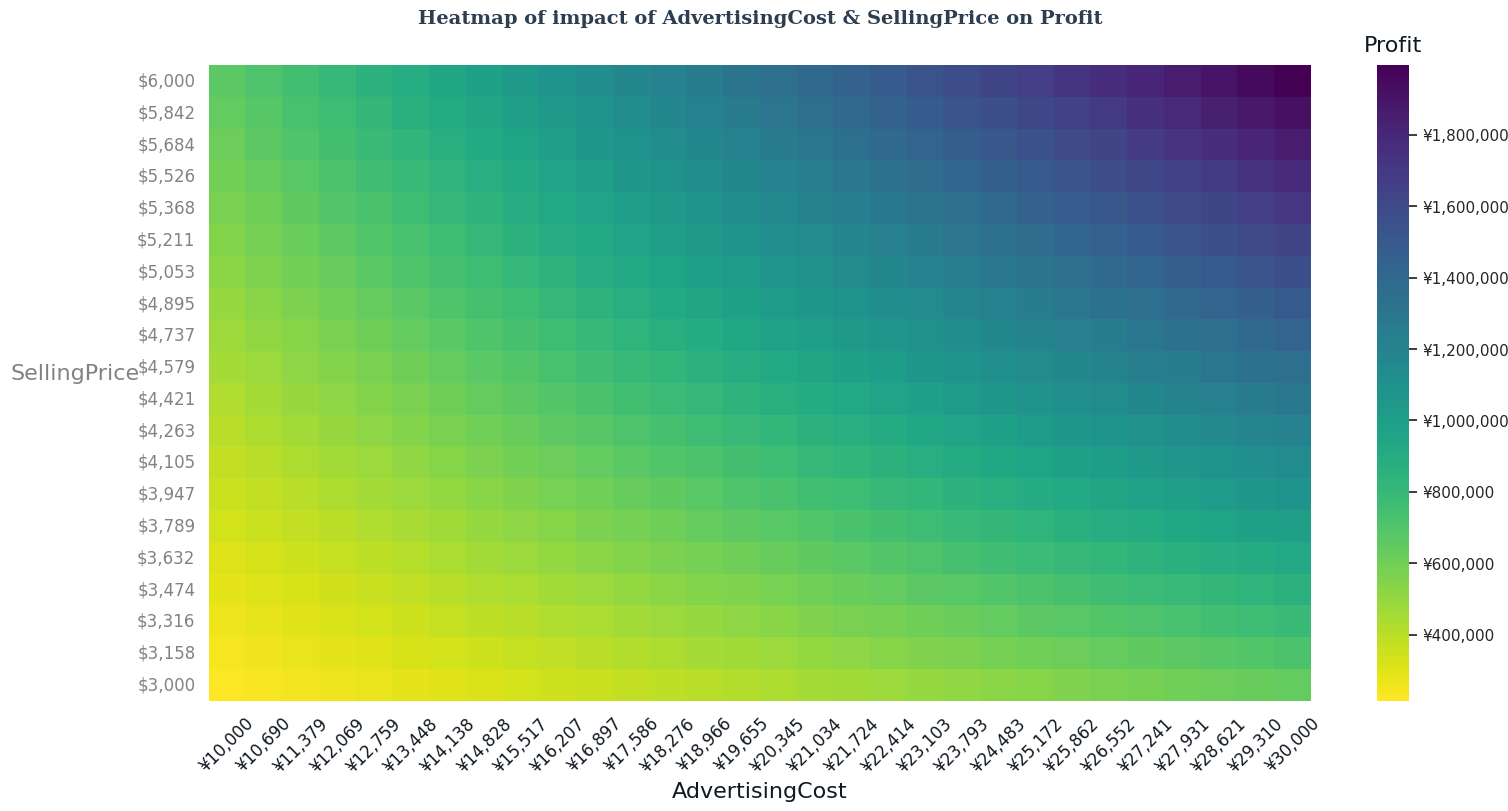

In [10]:
figure = generate_heatmap_from_df(two_way_analysis_df, variable_names.PROFIT)
plt.show()